In [7]:
# Setup
import random
import numpy as np
import pandas as pd
from scipy.stats import norm, t, uniform, triang, beta, gamma
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import matplotlib.animation as animation
from IPython.display import HTML

### Gridworld Example with Animation

Training complete!
Final path taken by the agent:
[(19, 1), (np.int64(19), np.int64(2)), (np.int64(19), np.int64(3)), (np.int64(19), np.int64(4)), (np.int64(19), np.int64(5)), (np.int64(19), np.int64(6)), (np.int64(19), np.int64(7)), (np.int64(19), np.int64(8)), (np.int64(19), np.int64(9)), (np.int64(19), np.int64(10)), (np.int64(19), np.int64(11)), (np.int64(18), np.int64(11)), (np.int64(17), np.int64(11)), (np.int64(17), np.int64(12)), (np.int64(17), np.int64(13)), (np.int64(16), np.int64(13)), (np.int64(15), np.int64(13)), (np.int64(14), np.int64(13)), (np.int64(14), np.int64(14)), (np.int64(14), np.int64(15)), (np.int64(14), np.int64(16)), (np.int64(14), np.int64(17)), (np.int64(13), np.int64(17)), (np.int64(12), np.int64(17)), (np.int64(12), np.int64(18)), (np.int64(12), np.int64(19)), (np.int64(12), np.int64(20)), (np.int64(12), np.int64(21)), (np.int64(12), np.int64(22)), (np.int64(12), np.int64(23)), (np.int64(11), np.int64(23)), (np.int64(10), np.int64(23)), (np.int64(9), np.i

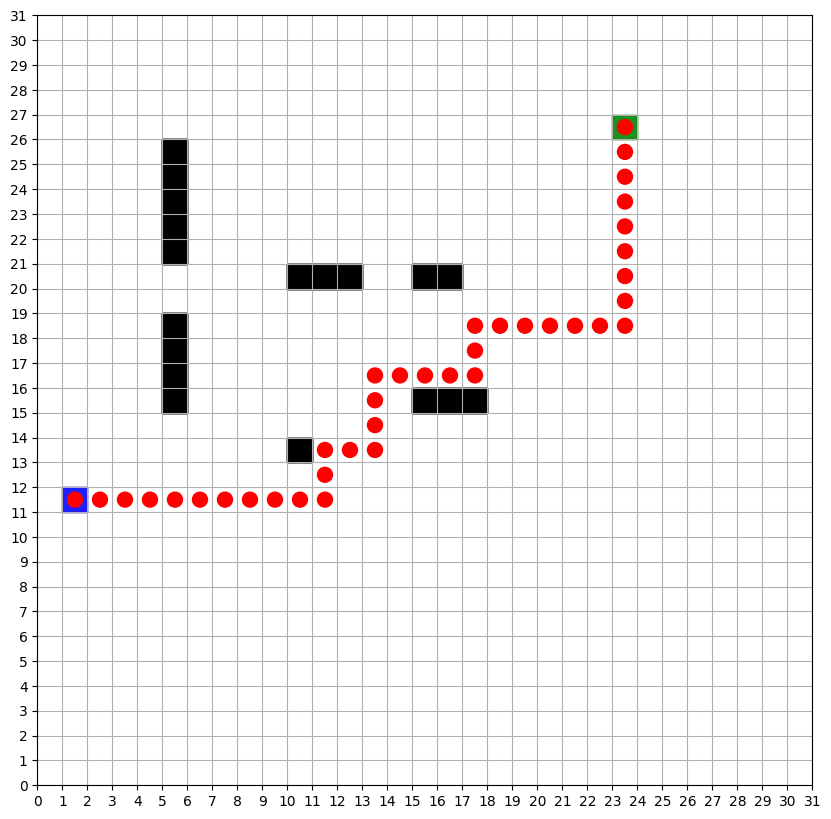

In [9]:
obstacles = [(5, 5), (6, 5), (7, 5), (8, 5), (9, 5), (12, 5), 
                          (13, 5), (14, 5), (15, 5),(10, 10), (10, 15), (10, 16),
                          (17, 10), (10, 11), (10, 12), (15, 15), (15, 16), (15, 17)]

class GridWorld:
    def __init__(self, size=31, list_obstacles = obstacles):
        self.size = size
        self.start_state = (19, 1)
        self.goal_state = (4, 23)
        self.obstacles = list_obstacles
        self.reset()

    def reset(self):
        self.agent_position = self.start_state
        return self.agent_position

    def step(self, action):
        x, y = self.agent_position
        if action == 0:   # Up
            x -= 1
        elif action == 1: # Down
            x += 1
        elif action == 2: # Left
            y -= 1
        elif action == 3: # Right
            y += 1

        x = np.clip(x, 0, self.size - 1)
        y = np.clip(y, 0, self.size - 1)

        new_position = (x, y)
        if new_position in self.obstacles:
            new_position = self.agent_position # Prevent moving into obstacle
            reward = -0.2
        else:
            reward = -0.1

        self.agent_position = new_position

        if self.agent_position == self.goal_state:
            reward = 1.0
            done = True
        else:
            done = False

        return new_position, reward, done

    def render(self):
        grid = np.zeros((self.size, self.size), dtype=str)
        grid[:] = '.'
        for obstacle in self.obstacles:
            grid[obstacle] = 'X'
        grid[self.start_state] = 'S'
        grid[self.goal_state] = 'G'
        grid[self.agent_position] = 'A'
        print("\n".join(" ".join(row) for row in grid))
        print()

env = GridWorld()

# Initialize Q-table
q_table = np.zeros((env.size, env.size, 4))

# Hyperparameters
alpha = 0.1   # Learning rate
gamma = 0.9  # Discount factor
epsilon = 0.3 # Exploration rate

# Training the agent
num_episodes = 6000  # Increased number of episodes for larger grid

for episode in range(num_episodes):
    state = env.reset()
    done = False
    steps = 0 
    while not done and steps<31**2:
        if random.uniform(0, 1) < epsilon:
            action = random.choice([0, 1, 2, 3]) # Explore
        else:
            action = np.argmax(q_table[state[0], state[1]]) # Exploit

        next_state, reward, done = env.step(action)
        # if done:
        #  print('YAY')
        best_next_action = np.argmax(q_table[next_state[0], next_state[1]])
        q_table[state[0], state[1], action] = q_table[state[0], state[1], action] + \
            alpha * (reward + gamma * q_table[next_state[0], next_state[1], best_next_action] - q_table[state[0], state[1], action])
        
        state = next_state
        steps += 1

print("Training complete!")

# Test the trained agent and collect data for animation
state = env.reset()
done = False
positions = [state]

while not done:
    action = np.argmax(q_table[state[0], state[1]])
    next_state, _, done = env.step(action)
    positions.append(next_state)
    state = next_state

# Debugging: Print the positions
print("Final path taken by the agent:")
print(positions)

# Animation
fig, ax = plt.subplots(figsize=(10, 10))

def init():
    ax.set_xlim(0, env.size)
    ax.set_ylim(0, env.size)
    ax.set_xticks(np.arange(0, env.size+1, 1))
    ax.set_yticks(np.arange(0, env.size+1, 1))
    ax.grid()

    for obstacle in env.obstacles:
        rect = patches.Rectangle((obstacle[1], env.size - obstacle[0] - 1), 1, 1, linewidth=1, edgecolor='black', facecolor='black')
        ax.add_patch(rect)

    rect_start = patches.Rectangle((env.start_state[1], env.size - env.start_state[0] - 1), 1, 1, linewidth=1, edgecolor='blue', facecolor='blue', alpha=0.5)
    rect_goal = patches.Rectangle((env.goal_state[1], env.size - env.goal_state[0] - 1), 1, 1, linewidth=1, edgecolor='green', facecolor='green', alpha=0.5)
    ax.add_patch(rect_start)
    ax.add_patch(rect_goal)

    return []

def update(frame):
    for artist in ax.artists:
        artist.remove()
    position = positions[frame]
    circle = patches.Circle((position[1] + 0.5, env.size - position[0] - 0.5), 0.3, color='red')
    ax.add_artist(circle)
    return []

ani = animation.FuncAnimation(fig, update, frames=len(positions), init_func=init, blit=True, repeat=False)

# Save animation as a GIF
ani.save('gridworld_animation.gif', writer='pillow')

plt.show()

Training agent...
Episode 1000/6000 completed
Episode 2000/6000 completed
Episode 3000/6000 completed
Episode 4000/6000 completed
Episode 5000/6000 completed


Episode 6000/6000 completed
Training complete!
Final path taken by the agent:
Start: (19, 1) -> Goal: (4, 23)
Path length: 38 steps
Path coordinates (x, y): [(19, 1), (np.int64(18), np.int64(1)), (np.int64(17), np.int64(1)), (np.int64(16), np.int64(1)), (np.int64(15), np.int64(1)), (np.int64(14), np.int64(1)), (np.int64(13), np.int64(1)), (np.int64(12), np.int64(1)), (np.int64(11), np.int64(1)), (np.int64(10), np.int64(1)), (np.int64(9), np.int64(1)), (np.int64(9), np.int64(2)), (np.int64(8), np.int64(2)), (np.int64(7), np.int64(2)), (np.int64(6), np.int64(2)), (np.int64(5), np.int64(2)), (np.int64(4), np.int64(2)), (np.int64(4), np.int64(3)), (np.int64(4), np.int64(4)), (np.int64(4), np.int64(5)), (np.int64(4), np.int64(6)), (np.int64(4), np.int64(7)), (np.int64(4), np.int64(8)), (np.int64(4), np.int64(9)), (np.int64(4), np.int64(10)), (np.int64(4), np.int64(11)), (np.int64(4), np.int64(12)), (np.int64(4), np.int64(13)), (np.int64(4), np.int64(14)), (np.int64(4), np.int64(15)), (np.in

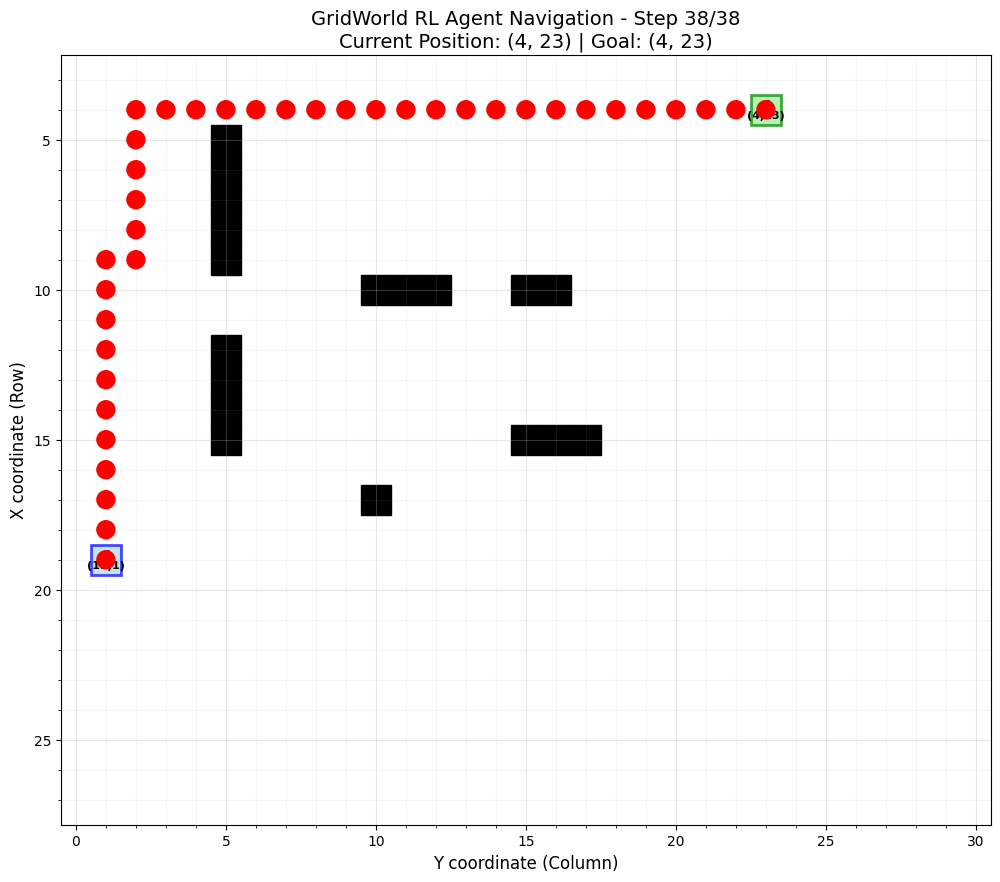

In [15]:
obstacles = [(5, 5), (6, 5), (7, 5), (8, 5), (9, 5), (12, 5), 
             (13, 5), (14, 5), (15, 5), (10, 10), (10, 15), (10, 16),
             (17, 10), (10, 11), (10, 12), (15, 15), (15, 16), (15, 17)]

class GridWorld:
    def __init__(self, size=31, list_obstacles=obstacles):
        self.size = size
        self.start_state = (19, 1)
        self.goal_state = (4, 23)
        self.obstacles = list_obstacles
        self.reset()

    def reset(self):
        self.agent_position = self.start_state
        return self.agent_position

    def step(self, action):
        x, y = self.agent_position
        if action == 0:   # Up
            x -= 1
        elif action == 1: # Down
            x += 1
        elif action == 2: # Left
            y -= 1
        elif action == 3: # Right
            y += 1

        x = np.clip(x, 0, self.size - 1)
        y = np.clip(y, 0, self.size - 1)

        new_position = (x, y)
        if new_position in self.obstacles:
            new_position = self.agent_position # Prevent moving into obstacle
            reward = -0.2
        else:
            reward = -0.1

        self.agent_position = new_position

        if self.agent_position == self.goal_state:
            reward = 1.0
            done = True
        else:
            done = False

        return new_position, reward, done

    def render(self):
        grid = np.zeros((self.size, self.size), dtype=str)
        grid[:] = '.'
        for obstacle in self.obstacles:
            grid[obstacle] = 'X'
        grid[self.start_state] = 'S'
        grid[self.goal_state] = 'G'
        grid[self.agent_position] = 'A'
        print("\n".join(" ".join(row) for row in grid))
        print()

env = GridWorld()

# Initialize Q-table
q_table = np.zeros((env.size, env.size, 4))

# Hyperparameters
alpha = 0.1   # Learning rate
gamma = 0.9   # Discount factor
epsilon = 0.25 # Exploration rate

# Training the agent
num_episodes = 6000

print("Training agent...")
for episode in range(num_episodes):
    state = env.reset()
    done = False
    steps = 0 
    while not done and steps < 31**2:
        if random.uniform(0, 1) < epsilon:
            action = random.choice([0, 1, 2, 3]) # Explore
        else:
            action = np.argmax(q_table[state[0], state[1]]) # Exploit

        next_state, reward, done = env.step(action)
        best_next_action = np.argmax(q_table[next_state[0], next_state[1]])
        q_table[state[0], state[1], action] = q_table[state[0], state[1], action] + \
            alpha * (reward + gamma * q_table[next_state[0], next_state[1], best_next_action] - q_table[state[0], state[1], action])
        
        state = next_state
        steps += 1

    if (episode + 1) % 1000 == 0:
        print(f"Episode {episode + 1}/{num_episodes} completed")

print("Training complete!")

# Test the trained agent and collect data for animation
state = env.reset()
done = False
positions = [state]

while not done:
    action = np.argmax(q_table[state[0], state[1]])
    next_state, _, done = env.step(action)
    positions.append(next_state)
    state = next_state

# Debugging: Print the positions
print("Final path taken by the agent:")
print(f"Start: {env.start_state} -> Goal: {env.goal_state}")
print(f"Path length: {len(positions)} steps")
print("Path coordinates (x, y):", positions)

# Animation with FIXED axis labels
fig, ax = plt.subplots(figsize=(12, 10))

def init():
    ax.clear()
    
    # Set up the coordinate system to match your grid representation
    # Your grid uses (x, y) where x is row (0 at top) and y is column (0 at left)
    ax.set_xlim(-0.5, env.size - 0.5)
    ax.set_ylim(-0.5, env.size - 0.5)
    ax.axis('equal')
    
    # Invert y-axis so (0,0) is at top-left, matching your grid representation
    ax.invert_yaxis()
    
    # Set proper labels
    ax.set_xlabel('Y coordinate (Column)', fontsize=12)
    ax.set_ylabel('X coordinate (Row)', fontsize=12)
    ax.set_title('GridWorld RL Agent Navigation\n(Red circle = Agent, Blue = Start, Green = Goal, Black = Obstacles)', fontsize=14)
    
    # Add grid lines
    ax.set_xticks(np.arange(0, env.size, 5))
    ax.set_yticks(np.arange(0, env.size, 5))
    ax.grid(True, alpha=0.3)
    
    # Add minor ticks for better visualization
    ax.set_xticks(np.arange(0, env.size, 1), minor=True)
    ax.set_yticks(np.arange(0, env.size, 1), minor=True)
    ax.grid(True, alpha=0.1, which='minor')

    # Draw obstacles (black squares)
    for obstacle in env.obstacles:
        x, y = obstacle  # x is row, y is column
        rect = patches.Rectangle((y - 0.5, x - 0.5), 1, 1, 
                               linewidth=1, edgecolor='black', facecolor='black')
        ax.add_patch(rect)

    # Draw start position (blue square)
    start_x, start_y = env.start_state
    rect_start = patches.Rectangle((start_y - 0.5, start_x - 0.5), 1, 1, 
                                 linewidth=2, edgecolor='blue', facecolor='lightblue', alpha=0.7)
    ax.add_patch(rect_start)
    
    # Draw goal position (green square)
    goal_x, goal_y = env.goal_state
    rect_goal = patches.Rectangle((goal_y - 0.5, goal_x - 0.5), 1, 1, 
                                linewidth=2, edgecolor='green', facecolor='lightgreen', alpha=0.7)
    ax.add_patch(rect_goal)
    
    # Add coordinate labels for start and goal
    ax.text(start_y, start_x, f'S\n({start_x},{start_y})', 
            ha='center', va='center', fontweight='bold', fontsize=8)
    ax.text(goal_y, goal_x, f'G\n({goal_x},{goal_y})', 
            ha='center', va='center', fontweight='bold', fontsize=8)

    return []

def update(frame):
    # Remove previous agent position
    for artist in ax.artists:
        if hasattr(artist, '_agent_marker'):
            artist.remove()
    
    # Draw agent at current position
    position = positions[frame]
    x, y = position  # x is row, y is column
    circle = patches.Circle((y, x), 0.3, color='red', zorder=10)
    circle._agent_marker = True  # Mark this as the agent marker
    ax.add_artist(circle)
    
    # Update title with current step
    ax.set_title(f'GridWorld RL Agent Navigation - Step {frame + 1}/{len(positions)}\n' +
                f'Current Position: ({x}, {y}) | Goal: ({env.goal_state[0]}, {env.goal_state[1]})', 
                fontsize=14)
    
    return [circle]

# Create animation
ani = animation.FuncAnimation(fig, update, frames=len(positions), 
                            init_func=init, blit=False, repeat=True, interval=500)

# Display coordinate system explanation
print("\n" + "="*60)
print("COORDINATE SYSTEM EXPLANATION:")
print("="*60)
print("Grid coordinates: (x, y) where:")
print("  - x = row number (0 at top, increases downward)")
print("  - y = column number (0 at left, increases rightward)")
print(f"Start position: {env.start_state} = Row {env.start_state[0]}, Column {env.start_state[1]}")
print(f"Goal position: {env.goal_state} = Row {env.goal_state[0]}, Column {env.goal_state[1]}")
print("="*60)


# plt.tight_layout()


# Optionally save as GIF (uncomment if needed)
ani.save('gridworld_animation.gif', dpi=120, savefig_kwargs={'bbox_inches': 'tight'}, writer='pillow', fps=8)

# Print final statistics
print(f"\nTraining Results:")
print(f"Total episodes: {num_episodes}")
print(f"Final path length: {len(positions)} steps")
print(f"Agent successfully reached goal: {'Yes' if positions[-1] == env.goal_state else 'No'}")

plt.show()

Episode 1000/1000 completed
Training complete!
Final path taken by the agent:
Start: (19, 1) -> Goal: (4, 23)
Path length: 38 steps
Path coordinates (x, y): [(19, 1), (np.int64(19), np.int64(2)), (np.int64(19), np.int64(3)), (np.int64(19), np.int64(4)), (np.int64(19), np.int64(5)), (np.int64(19), np.int64(6)), (np.int64(19), np.int64(7)), (np.int64(19), np.int64(8)), (np.int64(19), np.int64(9)), (np.int64(19), np.int64(10)), (np.int64(19), np.int64(11)), (np.int64(19), np.int64(12)), (np.int64(19), np.int64(13)), (np.int64(19), np.int64(14)), (np.int64(19), np.int64(15)), (np.int64(19), np.int64(16)), (np.int64(19), np.int64(17)), (np.int64(19), np.int64(18)), (np.int64(19), np.int64(19)), (np.int64(19), np.int64(20)), (np.int64(19), np.int64(21)), (np.int64(18), np.int64(21)), (np.int64(17), np.int64(21)), (np.int64(16), np.int64(21)), (np.int64(16), np.int64(22)), (np.int64(16), np.int64(23)), (np.int64(15), np.int64(23)), (np.int64(14), np.int64(23)), (np.int64(13), np.int64(23)), (

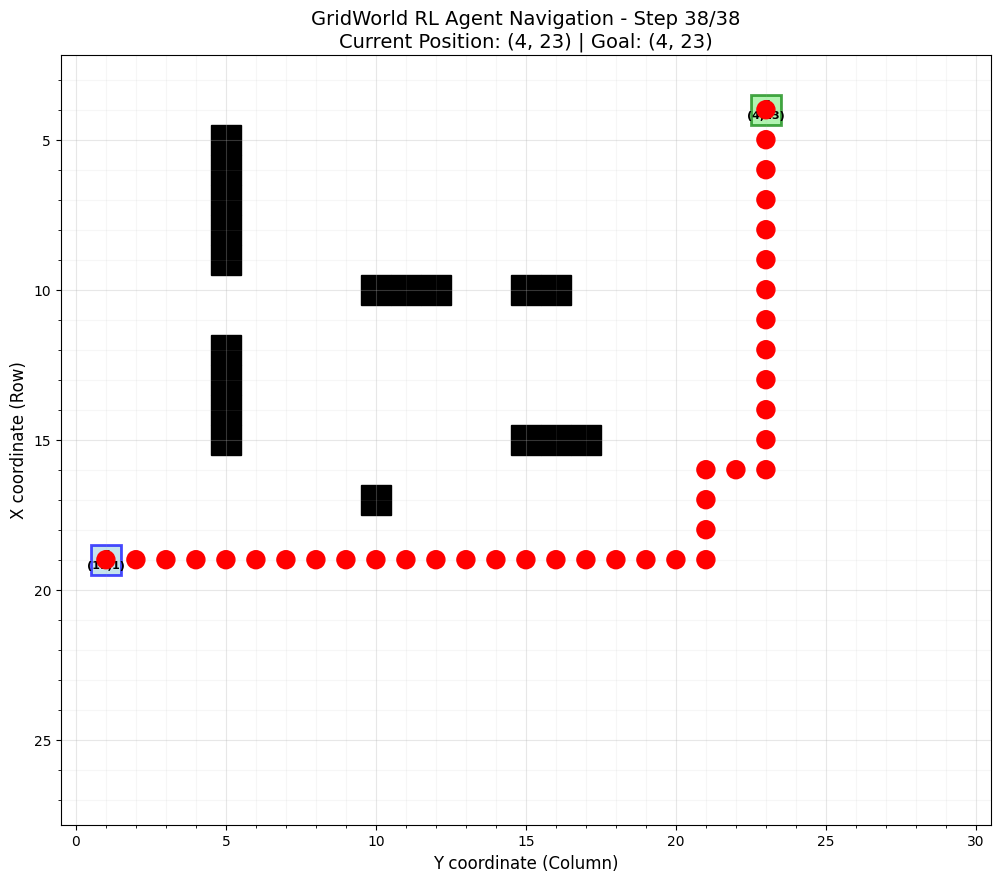

In [18]:
# Solve the same problem by using the UCB strategy for action-selection
obstacles = [(5, 5), (6, 5), (7, 5), (8, 5), (9, 5), (12, 5), 
             (13, 5), (14, 5), (15, 5), (10, 10), (10, 15), (10, 16),
             (17, 10), (10, 11), (10, 12), (15, 15), (15, 16), (15, 17)]

class GridWorld:
    def __init__(self, size=31, obstacles=obstacles):
        self.size = size
        self.start_state = (19, 1)
        self.goal_state = (4, 23)
        self.obstacles = obstacles
        self.reset()

    def reset(self):
        self.agent_position = self.start_state
        return self.agent_position

    def step(self, action):
        x, y = self.agent_position
        if action == 0:   # Up
            x -= 1
        elif action == 1: # Down
            x += 1
        elif action == 2: # Left
            y -= 1
        elif action == 3: # Right
            y += 1

        x = np.clip(x, 0, self.size - 1)
        y = np.clip(y, 0, self.size - 1)

        new_position = (x, y)
        if new_position in self.obstacles:
            new_position = self.agent_position  # Prevent moving into obstacle
            reward = -0.2 # (double the negative rewrd for going into an obstacle)
        else:
            reward = -0.1

        self.agent_position = new_position

        if self.agent_position == self.goal_state:
            reward = 1.0
            done = True
        else:
            done = False

        return new_position, reward, done

    def render(self):
        grid = np.zeros((self.size, self.size), dtype=str)
        grid[:] = '.'
        for obstacle in self.obstacles:
            grid[obstacle] = 'X'
        grid[self.start_state] = 'S'
        grid[self.goal_state] = 'G'
        grid[self.agent_position] = 'A'
        print("\n".join(" ".join(row) for row in grid))
        print()

env = GridWorld()

# Initialize Q-table and N-table
q_table = np.zeros((env.size, env.size, 4))
n_table = np.zeros((env.size, env.size, 4))

# Hyperparameters
alpha = 0.1   # Learning rate
gamma = 0.9  # Discount factor
c = 2.0      # Degree of exploration for UCB

def select_action(state, episode):
    ucb_values = q_table[state[0], state[1]] + c * np.sqrt(np.log(episode + 1) / (n_table[state[0], state[1]] + 1e-5))
    return np.argmax(ucb_values)

# Training the agent
num_episodes = 1000  # Increased number of episodes for larger grid

for episode in range(num_episodes):
    state = env.reset()
    done = False
    steps = 0
    while not done and steps<31**2 :
        action = select_action(state, episode)

        next_state, reward, done = env.step(action)
        n_table[state[0], state[1], action] += 1
        best_next_action = np.argmax(q_table[next_state[0], next_state[1]])
        q_table[state[0], state[1], action] = q_table[state[0], state[1], action] + \
            alpha * (reward + gamma * q_table[next_state[0], next_state[1], best_next_action] - q_table[state[0], state[1], action])

        state = next_state
        steps += 1
    if (episode + 1) % 1000 == 0:
        print(f"Episode {episode + 1}/{num_episodes} completed")

print("Training complete!")

# Test the trained agent and collect data for animation
state = env.reset()
done = False
positions = [state]

while not done:
    action = np.argmax(q_table[state[0], state[1]])
    next_state, _, done = env.step(action)
    positions.append(next_state)
    state = next_state

# Debugging: Print the positions
print("Final path taken by the agent:")
print(f"Start: {env.start_state} -> Goal: {env.goal_state}")
print(f"Path length: {len(positions)} steps")
print("Path coordinates (x, y):", positions)


# Test the trained agent and collect data for animation
state = env.reset()
done = False
positions = [state]

while not done:
    action = np.argmax(q_table[state[0], state[1]])
    next_state, _, done = env.step(action)
    positions.append(next_state)
    state = next_state

# Debugging: Print the positions
print("Final path taken by the agent:")
print(positions)

# Animation with FIXED axis labels
fig, ax = plt.subplots(figsize=(12, 10))

def init():
    ax.clear()
    
    # Set up the coordinate system to match your grid representation
    # Your grid uses (x, y) where x is row (0 at top) and y is column (0 at left)
    ax.set_xlim(-0.5, env.size - 0.5)
    ax.set_ylim(-0.5, env.size - 0.5)
    ax.axis('equal')
    
    # Invert y-axis so (0,0) is at top-left, matching your grid representation
    ax.invert_yaxis()
    
    # Set proper labels
    ax.set_xlabel('Y coordinate (Column)', fontsize=12)
    ax.set_ylabel('X coordinate (Row)', fontsize=12)
    ax.set_title('GridWorld RL Agent Navigation\n(Red circle = Agent, Blue = Start, Green = Goal, Black = Obstacles)', fontsize=14)
    
    # Add grid lines
    ax.set_xticks(np.arange(0, env.size, 5))
    ax.set_yticks(np.arange(0, env.size, 5))
    ax.grid(True, alpha=0.3)
    
    # Add minor ticks for better visualization
    ax.set_xticks(np.arange(0, env.size, 1), minor=True)
    ax.set_yticks(np.arange(0, env.size, 1), minor=True)
    ax.grid(True, alpha=0.1, which='minor')

    # Draw obstacles (black squares)
    for obstacle in env.obstacles:
        x, y = obstacle  # x is row, y is column
        rect = patches.Rectangle((y - 0.5, x - 0.5), 1, 1, 
                               linewidth=1, edgecolor='black', facecolor='black')
        ax.add_patch(rect)

    # Draw start position (blue square)
    start_x, start_y = env.start_state
    rect_start = patches.Rectangle((start_y - 0.5, start_x - 0.5), 1, 1, 
                                 linewidth=2, edgecolor='blue', facecolor='lightblue', alpha=0.7)
    ax.add_patch(rect_start)
    
    # Draw goal position (green square)
    goal_x, goal_y = env.goal_state
    rect_goal = patches.Rectangle((goal_y - 0.5, goal_x - 0.5), 1, 1, 
                                linewidth=2, edgecolor='green', facecolor='lightgreen', alpha=0.7)
    ax.add_patch(rect_goal)
    
    # Add coordinate labels for start and goal
    ax.text(start_y, start_x, f'S\n({start_x},{start_y})', 
            ha='center', va='center', fontweight='bold', fontsize=8)
    ax.text(goal_y, goal_x, f'G\n({goal_x},{goal_y})', 
            ha='center', va='center', fontweight='bold', fontsize=8)

    return []

def update(frame):
    # Remove previous agent position
    for artist in ax.artists:
        if hasattr(artist, '_agent_marker'):
            artist.remove()
    
    # Draw agent at current position
    position = positions[frame]
    x, y = position  # x is row, y is column
    circle = patches.Circle((y, x), 0.3, color='red', zorder=10)
    circle._agent_marker = True  # Mark this as the agent marker
    ax.add_artist(circle)
    
    # Update title with current step
    ax.set_title(f'GridWorld RL Agent Navigation - Step {frame + 1}/{len(positions)}\n' +
                f'Current Position: ({x}, {y}) | Goal: ({env.goal_state[0]}, {env.goal_state[1]})', 
                fontsize=14)
    
    return [circle]

# Create animation
ani = animation.FuncAnimation(fig, update, frames=len(positions), 
                            init_func=init, blit=False, repeat=True, interval=500)

# Display coordinate system explanation
print("\n" + "="*60)
print("COORDINATE SYSTEM EXPLANATION:")
print("="*60)
print("Grid coordinates: (x, y) where:")
print("  - x = row number (0 at top, increases downward)")
print("  - y = column number (0 at left, increases rightward)")
print(f"Start position: {env.start_state} = Row {env.start_state[0]}, Column {env.start_state[1]}")
print(f"Goal position: {env.goal_state} = Row {env.goal_state[0]}, Column {env.goal_state[1]}")
print("="*60)


# plt.tight_layout()


# Optionally save as GIF (uncomment if needed)
ani.save('gridworld_animation.gif', dpi=120, savefig_kwargs={'bbox_inches': 'tight'}, writer='pillow', fps=8)

# Print final statistics
print(f"\nTraining Results:")
print(f"Total episodes: {num_episodes}")
print(f"Final path length: {len(positions)} steps")
print(f"Agent successfully reached goal: {'Yes' if positions[-1] == env.goal_state else 'No'}")

plt.show()